# Statistics

After running a simulation, you often want to compute summary statistics
— both for your own understanding and for communicating results.

Examples of statistics:

- Min, max, mean, standard deviation
- Quantiles/percentiles (e.g. median, interquartile range)
- Probability/frequency of exceedance

Types of aggregations:

- **Temporal** — aggregate all time steps; for a 2D file, the result is
  a spatial map
- **Spatial** — aggregate all elements to a single value per time step
- **Total** — aggregate all data to a single number

Ways of calculating:

- [`mikeio.Dataset`](../api/Dataset.html#mikeio.Dataset) /
  [`mikeio.DataArray`](../api/DataArray.html#mikeio.DataArray) —
  in-memory, flexible
- [`mikeio.generic`](generic.qmd) — temporal aggregations on any dfs
  file, out-of-core for large files
- Custom code with NumPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mikeio
import mikeio.generic

In [2]:
ds = mikeio.read("../data/NorthSea_HD_and_windspeed.dfsu")
ds

<mikeio.Dataset>
dims: (time:67, element:958)
time: 2017-10-27 00:00:00 - 2017-10-29 18:00:00 (67 records)
geometry: Dfsu2D (958 elements, 570 nodes)
items:
  0:  Surface elevation <Surface Elevation> (meter)
  1:  Wind speed <Wind speed> (meter per sec)

## Temporal aggregations

The default aggregation axis is time — the output is a spatial map.

### Mean

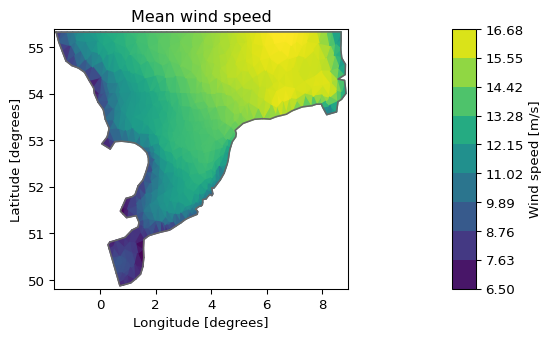

In [3]:
ds_mean = ds.mean()
ds_mean["Wind speed"].plot(title="Mean wind speed");

### Max

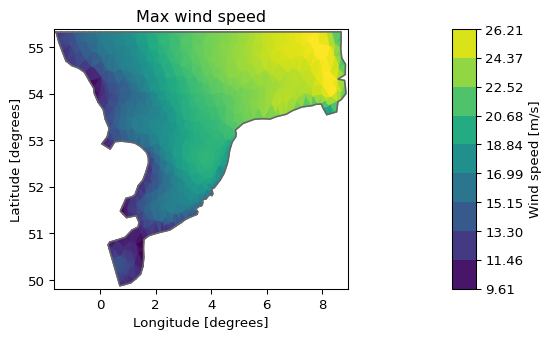

In [4]:
ds.max()["Wind speed"].plot(title="Max wind speed");

### Quantiles

In [5]:
ds_q = ds.quantile(q=[0.1, 0.5, 0.9])
ds_q

<mikeio.Dataset>
dims: (element:958)
time: 2017-10-27 00:00:00 (time-invariant)
geometry: Dfsu2D (958 elements, 570 nodes)
items:
  0:  Quantile 0.1, Surface elevation <Surface Elevation> (meter)
  1:  Quantile 0.5, Surface elevation <Surface Elevation> (meter)
  2:  Quantile 0.9, Surface elevation <Surface Elevation> (meter)
  3:  Quantile 0.1, Wind speed <Wind speed> (meter per sec)
  4:  Quantile 0.5, Wind speed <Wind speed> (meter per sec)
  5:  Quantile 0.9, Wind speed <Wind speed> (meter per sec)

The quantile results can be written to a new dfsu file:

In [6]:
ds_q.to_dfs("NorthSea_quantiles.dfsu")

### Custom aggregations

Use `aggregate()` with any function that reduces along an axis:

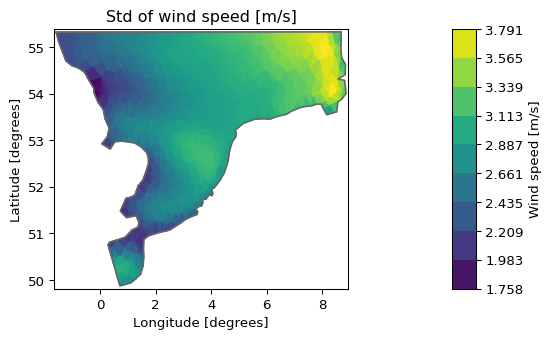

In [7]:
ds_std = ds.aggregate(func=np.std)
ds_std["Wind speed"].plot(title="Std of wind speed [m/s]");

## Spatial aggregations

Pass `axis="space"` to aggregate all elements into a time series.

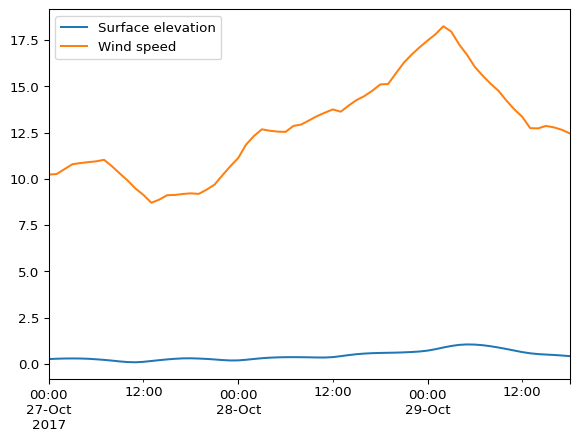

In [8]:
ds.mean(axis="space").plot();

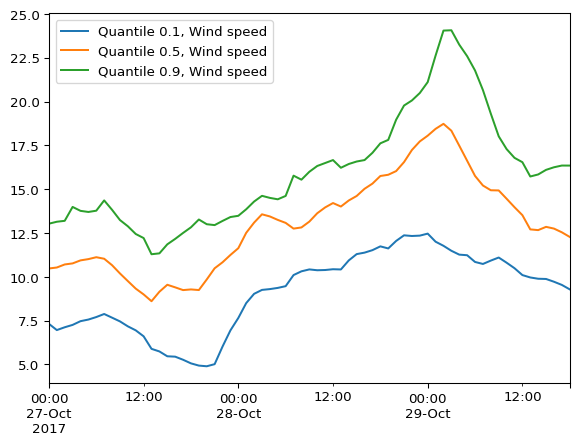

In [9]:
ds.Wind_speed.quantile(q=[0.1, 0.5, 0.9], axis="space").plot();

> **Warning**
>
> `mean(axis="space")` ignores element areas — all elements are weighted
> equally. For area-weighted averages, use `average()` with explicit
> weights.

### Weighted spatial average

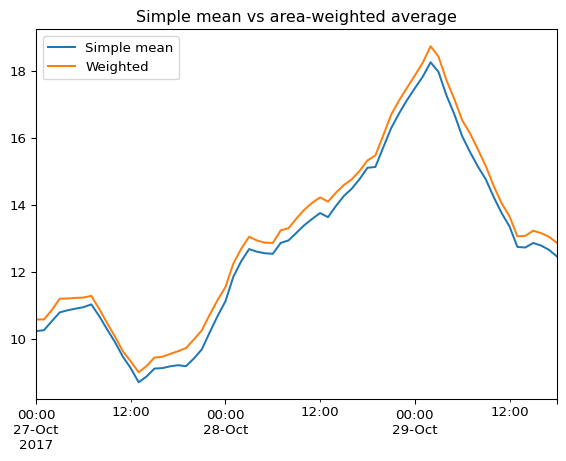

In [10]:
area = ds.geometry.get_element_area()

df_compare = (
    ds[["Wind speed"]]
    .mean(axis="space")
    .to_dataframe()
    .rename(columns={"Wind speed": "Simple mean"})
)
df_compare["Weighted"] = (
    ds[["Wind speed"]]
    .average(axis="space", weights=area)
    .to_dataframe()
    .values
)
df_compare.plot(title="Simple mean vs area-weighted average");

## Total aggregations

Aggregate over both time and space.

In [11]:
ds.describe()

In [12]:
ds.min(axis=None).to_dataframe()

## Out-of-core statistics (generic)

For large files that don’t fit in memory, use
[`mikeio.generic`](generic.qmd) to compute temporal statistics directly
on disk:

In [13]:
mikeio.generic.avg_time(
    "../data/NorthSea_HD_and_windspeed.dfsu",
    "NorthSea_avg.dfsu",
)


100%|██████████| 66/66 [00:00<00:00, 27841.10it/s]

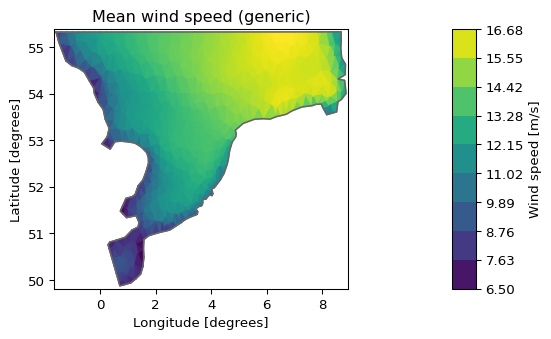

In [14]:
mikeio.read("NorthSea_avg.dfsu", items="Wind speed")["Wind speed"].plot(
    title="Mean wind speed (generic)"
);

In [15]:
mikeio.generic.quantile(
    "../data/NorthSea_HD_and_windspeed.dfsu",
    "NorthSea_quantiles_generic.dfsu",
    q=[0.1, 0.5, 0.9],
)

## Exceedance probability

Calculate the fraction of time a threshold is exceeded at each location.

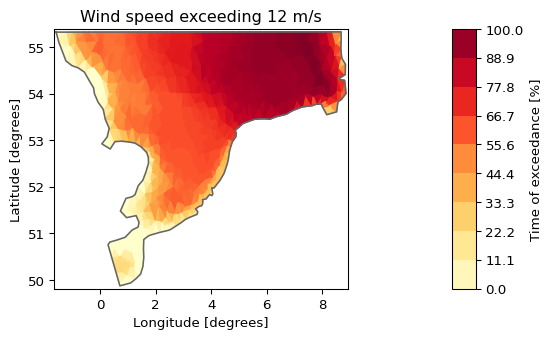

In [16]:
threshold = 12  # m/s
wind = ds["Wind speed"].values  # shape: (time, element)
n_exceed = np.sum(wind > threshold, axis=0)
prob_exceed = n_exceed / ds.n_timesteps

item = mikeio.ItemInfo("Exceedance probability", mikeio.EUMType.Probability)
da_exc = mikeio.DataArray(
    data=prob_exceed * 100,
    time=ds.time[0],
    item=item,
    geometry=ds.geometry,
)
da_exc.plot(
    title=f"Wind speed exceeding {threshold} m/s",
    label="Time of exceedance [%]",
    cmap="YlOrRd",
);

Cleanup temporary files:

In [17]:
import os

for f in [
    "NorthSea_quantiles.dfsu",
    "NorthSea_avg.dfsu",
    "NorthSea_quantiles_generic.dfsu",
]:
    if os.path.exists(f):
        os.remove(f)